# **EDA - Exploratory Data Analysis**
## Metadata + Image

### *1. Importing All Necessary Libraries*

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import LabelEncoder

### *2. Configuring Paths & Mapping*

In [2]:
from pathlib import Path
BASE_DIR = Path.cwd()
csv_path = BASE_DIR / "HAM10000_metadata_cleaned.csv"

folder_dir = BASE_DIR / "chive"

image_files = [
    folder_dir / "HAM10000_images_part_1",
    folder_dir / "HAM10000_images_part_2",
]

RANDOM_SEED = 69
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Label Mapping
dx_short = {0:'akiec', 1:'bcc', 2:'bkl', 3:'df', 4:'mel', 5:'nv', 6:'vasc'}
dx_full  = {
    0: 'Actinic Keratoses (akiec)',
    1: 'Basal Cell Carcinoma (bcc)',
    2: 'Benign Keratosis (bkl)',
    3: 'Dermatofibroma (df)',
    4: 'Melanoma (mel)',
    5: 'Melanocytic Nevi (nv)',
    6: 'Vascular Lesions (vasc)',
}

# Color Mapping
order   = ['akiec','bcc','bkl','df','mel','nv','vasc']
palette = ['indianred','olive','tan','lightblue','gold','pink','navy']
color_map = dict(zip(order, palette))

# Explicitly listing images using image ID to exclude in the Image EDA, since they have no meta data.
# Number of images excluded = 57 images
EXCLUDE_IDS = {
    'ISIC_0032529','ISIC_0032578','ISIC_0032599','ISIC_0032667','ISIC_0032679',
    'ISIC_0032738','ISIC_0032740','ISIC_0032789','ISIC_0032814','ISIC_0032852',
    'ISIC_0032945','ISIC_0032946','ISIC_0032966','ISIC_0033028','ISIC_0033064',
    'ISIC_0033065','ISIC_0033119','ISIC_0033153','ISIC_0033187','ISIC_0033190',
    'ISIC_0033330','ISIC_0033332','ISIC_0033353','ISIC_0033374','ISIC_0033375',
    'ISIC_0033391','ISIC_0033417','ISIC_0033472','ISIC_0033490','ISIC_0033515',
    'ISIC_0033535','ISIC_0033597','ISIC_0033628','ISIC_0033631','ISIC_0033685',
    'ISIC_0033733','ISIC_0033735','ISIC_0033750','ISIC_0033751','ISIC_0033782',
    'ISIC_0033809','ISIC_0033829','ISIC_0033841','ISIC_0033864','ISIC_0033877',
    'ISIC_0033882','ISIC_0033982','ISIC_0034019','ISIC_0034045','ISIC_0034080',
    'ISIC_0034130','ISIC_0034154','ISIC_0034186','ISIC_0034195','ISIC_0034252',
    'ISIC_0034266','ISIC_0034283'
}

### *3. Verifying the Dataset & Lookup Directory for Image EDA*

In [3]:
# Verify csv exists and readable
print(csv_path, " , ", csv_path.exists())

# Verify images exist and readable
for folder in image_files:
    print(folder, " , ", folder.exists())

# Verifying images count found
from pathlib import Path
tt_img = 0
for folder in image_files:
    count = len(list(folder.glob("*.jpg")))
    print(folder.name, " : ",count)
    tt_img += count
print()

'''-------------------------------------
Image Lookup Directory for the Image EDA '''
# Makes image-path mappings available everywhere, reducing the need to build a dictionary everytime

image_path_dict = {}
for folder in image_files:
    for img_file in folder.glob("*.jpg"):
        image_path_dict[img_file.stem] = str(img_file)
print(f"Total Indexed Images: {len(image_path_dict)}")



c:\Users\shrin\OneDrive - University of Wollongong\CSCI 323\Project\HAM10000_metadata_cleaned.csv  ,  True
c:\Users\shrin\OneDrive - University of Wollongong\CSCI 323\Project\chive\HAM10000_images_part_1  ,  True
c:\Users\shrin\OneDrive - University of Wollongong\CSCI 323\Project\chive\HAM10000_images_part_2  ,  True
HAM10000_images_part_1  :  5000
HAM10000_images_part_2  :  5015

Total Indexed Images: 10015


### *4. Loading the Data & Feature Engineering*

In [4]:
df = pd.read_csv(csv_path)
df['dx_label'] = df['dx'].map(dx_short)
df['sex_label'] = df['sex'].map({0:'Female', 1:'Male'})
le = LabelEncoder()
df['localization_enc'] = le.fit_transform(df['localization'])
df.head(10)

,lesion_id,image_id,dx,age,sex,localization,dx_label,sex_label,localization_enc
0,HAM_0000118,ISIC_0027419,2,80,0,scalp,bkl,Female,11
1,HAM_0000118,ISIC_0025030,2,80,0,scalp,bkl,Female,11
2,HAM_0002730,ISIC_0026769,2,80,0,scalp,bkl,Female,11
3,HAM_0002730,ISIC_0025661,2,80,0,scalp,bkl,Female,11
4,HAM_0001466,ISIC_0031633,2,75,0,ear,bkl,Female,4
5,HAM_0001466,ISIC_0027850,2,75,0,ear,bkl,Female,4
6,HAM_0002761,ISIC_0029176,2,60,0,face,bkl,Female,5
7,HAM_0002761,ISIC_0029068,2,60,0,face,bkl,Female,5
8,HAM_0005132,ISIC_0025837,2,70,1,back,bkl,Male,2
9,HAM_0005132,ISIC_0025209,2,70,1,back,bkl,Male,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9958 entries, 0 to 9957
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   lesion_id         9958 non-null   str  
 1   image_id          9958 non-null   str  
 2   dx                9958 non-null   int64
 3   age               9958 non-null   int64
 4   sex               9958 non-null   int64
 5   localization      9958 non-null   str  
 6   dx_label          9958 non-null   str  
 7   sex_label         9958 non-null   str  
 8   localization_enc  9958 non-null   int64
dtypes: int64(4), str(5)
memory usage: 700.3 KB


# **Part 1:** Metadata EDA

### *5. Summarization of the Cleaned Dataset HAM10000*

In [6]:
print('=' * 30)
print(' DATASET SUMMARY')
print('=' * 30)

print(f'  Total images      :  {len(df):,}')
print(f'  Unique lesions    :  {df["lesion_id"].nunique():,}')
print(f'  Unique image IDs  :  {df["image_id"].nunique():,}')
print(f'  Avg images/lesion :  {len(df)/df["lesion_id"].nunique():.2f}')
print(f'  Duplicate rows    :  {df.duplicated().sum()}')
print(f'  Age range         :  {df["age"].min():.0f}–{df["age"].max():.0f} yrs')
print(f'  Diagnosis classes :  {df["dx"].nunique()}')

 DATASET SUMMARY
  Total images      :  9,958
  Unique lesions    :  7,420
  Unique image IDs  :  9,958
  Avg images/lesion :  1.34
  Duplicate rows    :  0
  Age range         :  0–85 yrs
  Diagnosis classes :  7


### *6. Missing Value Analysis*

In [7]:
# Includes columns from cleaned dataset & feature engineered columns
print('=' * 30)
print(' MISSING VALUES')
print('=' * 30)
print(df.isnull().sum())

 MISSING VALUES
lesion_id           0
image_id            0
dx                  0
age                 0
sex                 0
localization        0
dx_label            0
sex_label           0
localization_enc    0
dtype: int64


### **PLOT 1**   --   Class Distribution : *Bar Chart*

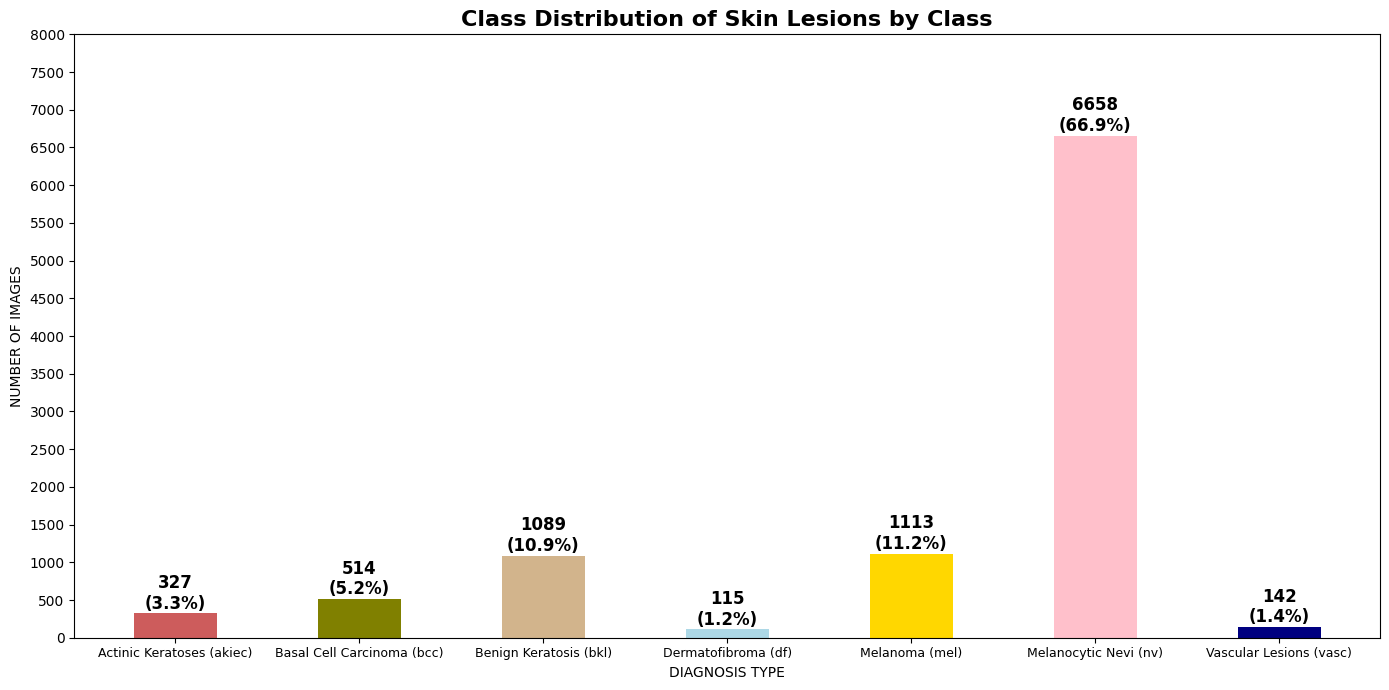

In [8]:
vc = df['dx'].value_counts().sort_index()
plt.figure(figsize=(14, 7))
bars = plt.bar([dx_full[i] for i in vc.index], vc.values, color=palette, width=0.45)

# Setting bar values for each skin lesion category
for bar, val in zip(bars, vc.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60, f'{val}\n({val/len(df)*100:.1f}%)', 
    ha='center', fontsize=12, fontweight='bold')

plt.title('Class Distribution of Skin Lesions by Class', fontsize=16, fontweight='bold')
plt.ylabel('NUMBER OF IMAGES')
plt.xlabel('DIAGNOSIS TYPE')
plt.ylim(0, 8000)
plt.yticks(range(0, 8001, 500))
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

### **PLOT 2**   --   Age Distribution per Class : *Boxplot*

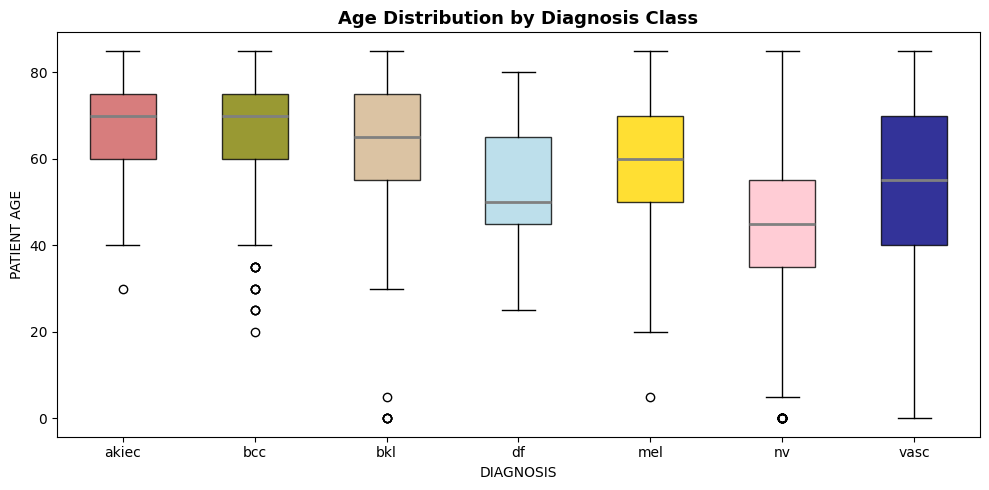

In [9]:
# Plot includes outliers in certain diagnosis classes, that fall beyond the whisker range
data_by_class = [df[df['dx_label'] == c]['age'].values for c in order]
plt.figure(figsize=(10, 5))

# medianprops for showing age median (grey line within box)
bp = plt.boxplot(data_by_class, tick_labels=order, patch_artist=True, medianprops=dict(color='grey', linewidth=2))

# Apply class colours to each box
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.title('Age Distribution by Diagnosis Class', fontsize=13, fontweight='bold')
plt.xlabel('DIAGNOSIS')
plt.ylabel('PATIENT AGE')
plt.tight_layout()
plt.show()

In [10]:
# Calculating the MEAN, MINIMUM & MAXIMUM of the age distributions per class
result = df.groupby('dx_label')['age'].agg(['mean','min','max']).round(1).reindex(order)
result.index.name = ''
print('=' * 30)
print('  AGE BY DIAGNOSIS')
print('=' * 30)
print(result.to_string())

  AGE BY DIAGNOSIS
       mean  min  max
                     
akiec  66.5   30   85
bcc    66.8   20   85
bkl    64.3    0   85
df     53.0   25   80
mel    60.7    5   85
nv     46.5    0   85
vasc   51.4    0   85


### **PLOT 3**   --   Sex Distribution per Class : *Grouped Bar*

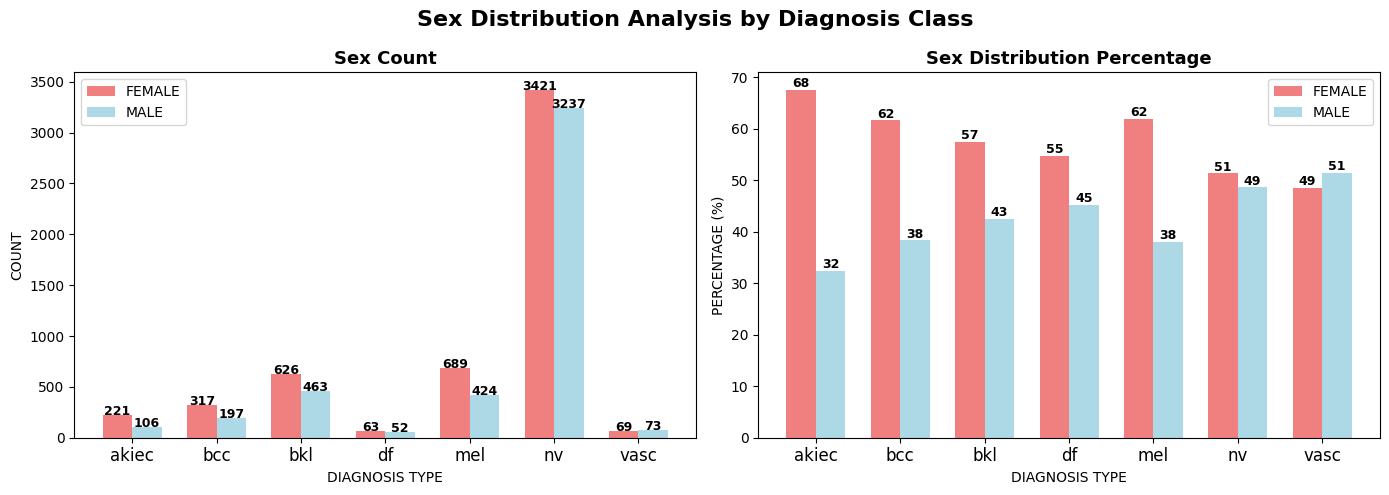

In [11]:
# Count of Female/Male per diagnosis class and converting to percentage
cross_abs = pd.crosstab(df['dx_label'], df['sex_label']).reindex(order)
cross_pct = cross_abs.div(cross_abs.sum(axis=1), axis=0) * 100

x, w = np.arange(len(order)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, ylabel in [
    (axes[0], cross_abs, 'Sex Count', 'COUNT'),
    (axes[1], cross_pct, 'Sex Distribution Percentage', 'PERCENTAGE (%)')
]:
    f_bars = ax.bar(x - w/2, data['Female'], w, label='FEMALE', color='lightcoral')
    m_bars = ax.bar(x + w/2, data['Male'],   w, label='MALE',   color='lightblue')

    # Adding value labels for each bar
    for bar in f_bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.0f}', 
        ha='center', fontsize=9, fontweight='bold')
    for bar in m_bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.0f}', 
        ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(order, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('DIAGNOSIS TYPE')
    ax.legend()

plt.suptitle('Sex Distribution Analysis by Diagnosis Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **PLOT 4**   --   Numeric Features Colored by Diagnosis : *Pairplot*

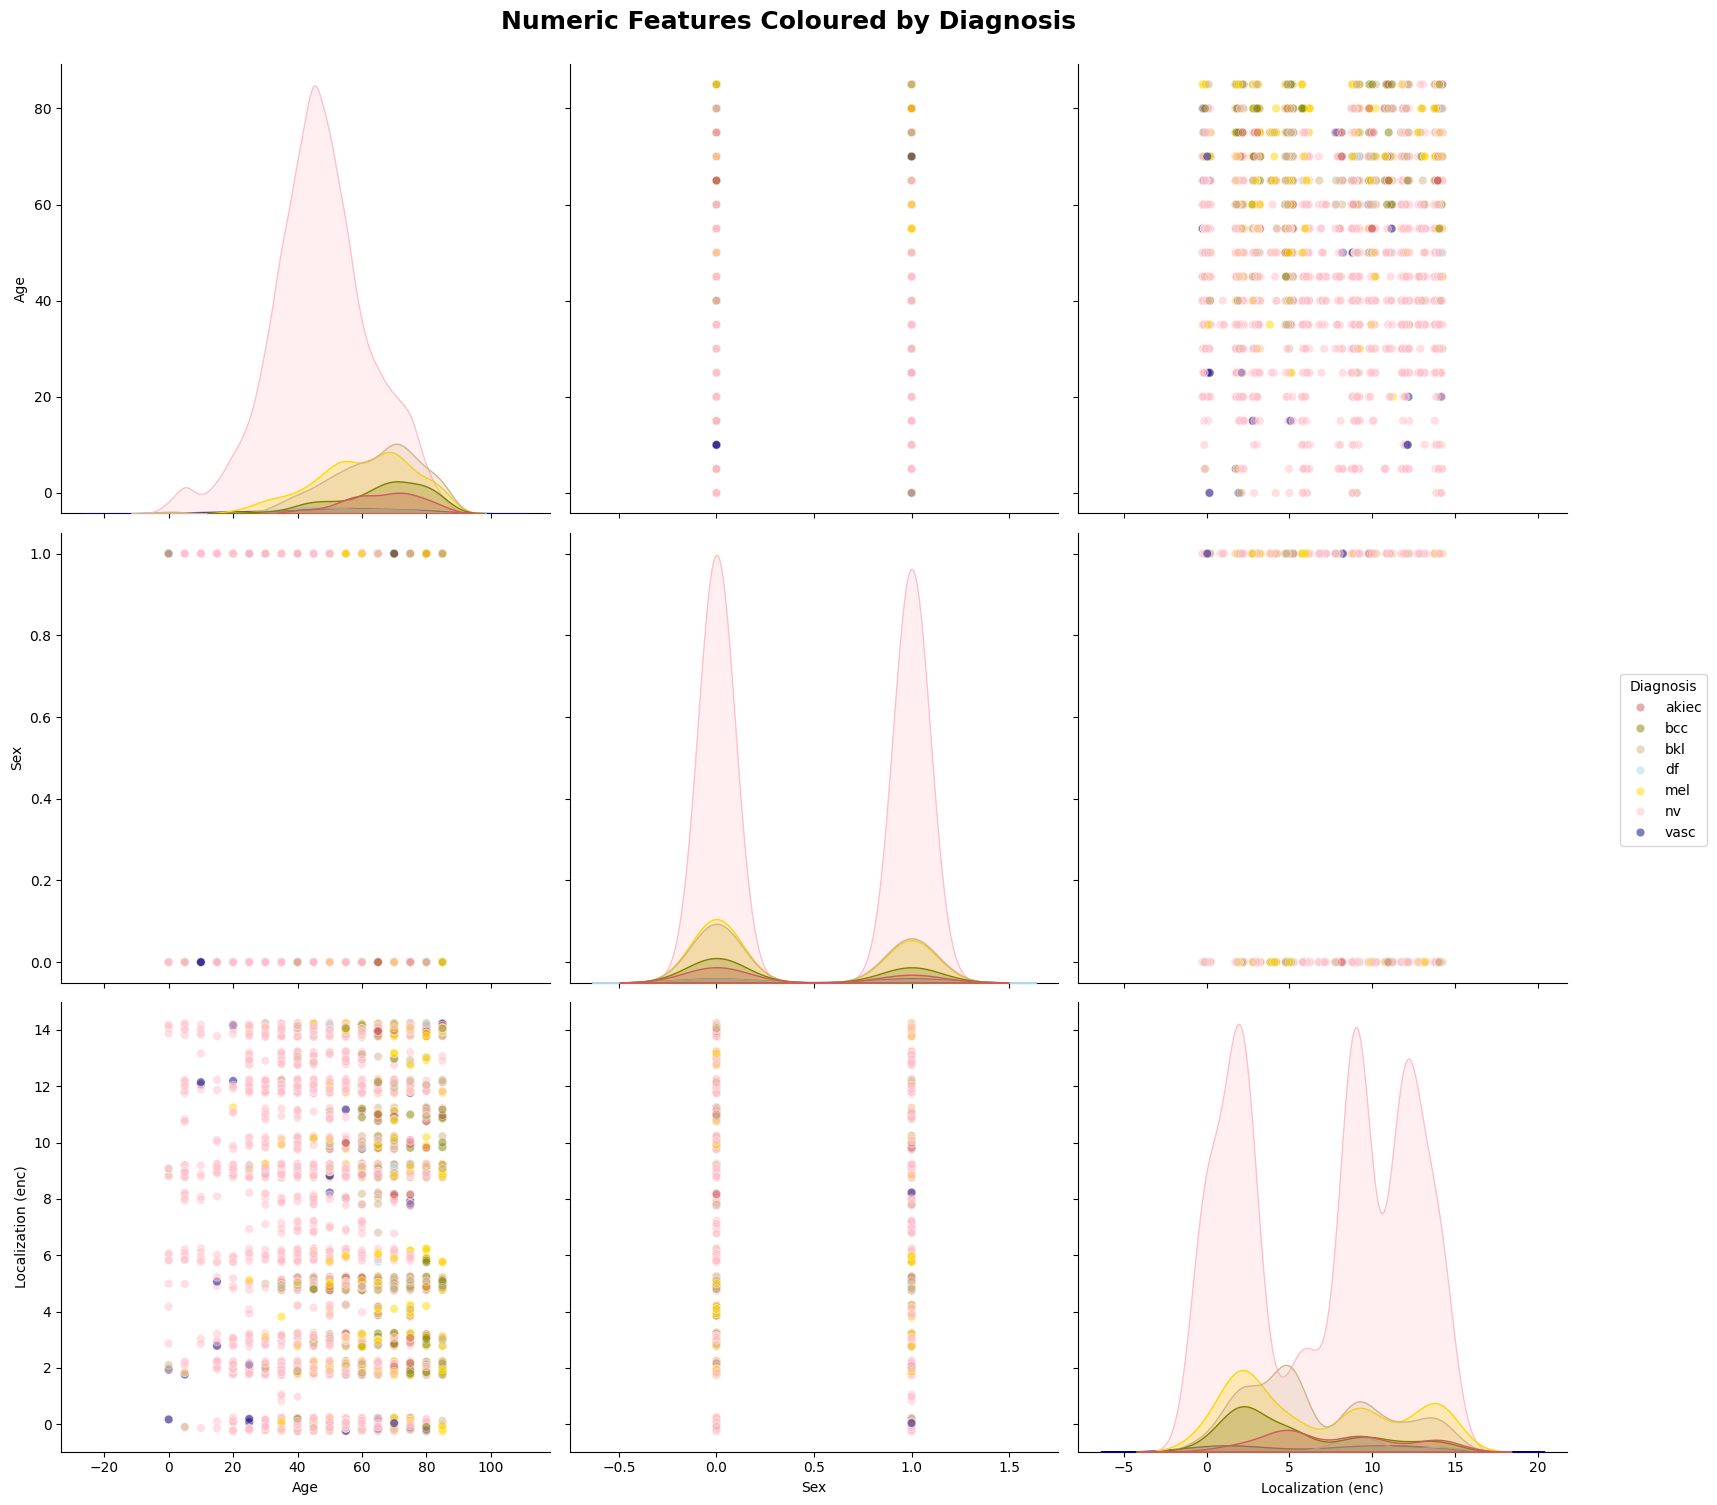

In [12]:
# Checking joint distributions across classes
pair_df = df[['age', 'sex', 'localization_enc', 'dx_label']].copy()
pair_df.columns = ['Age', 'Sex', 'Localization (enc)', 'Diagnosis']

# Sampling 6,000 rows reduces execution overhead
sample = pair_df.sample(n=6000, random_state=RANDOM_SEED)

# Applying horizontal jitter to 'Localization (enc)' to prevent overlapping of data points into single straight lines
sample['Localization (enc)'] = sample['Localization (enc)'] + np.random.uniform(-0.25, 0.25, size=len(sample))

g = sns.pairplot(sample, hue='Diagnosis', hue_order=order,
                 palette=color_map, diag_kind='kde',               # Displays probability density curves along the diagonal
                 plot_kws={'alpha': 0.5, 's': 38}, height=5.0)     # 'alpha' handles overplotting via transparency

sns.move_legend(g, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

g.fig.suptitle('Numeric Features Coloured by Diagnosis', fontsize=18, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


### **PLOT 5**   --   Localization Distribution : *Horizontal Bar Chart*

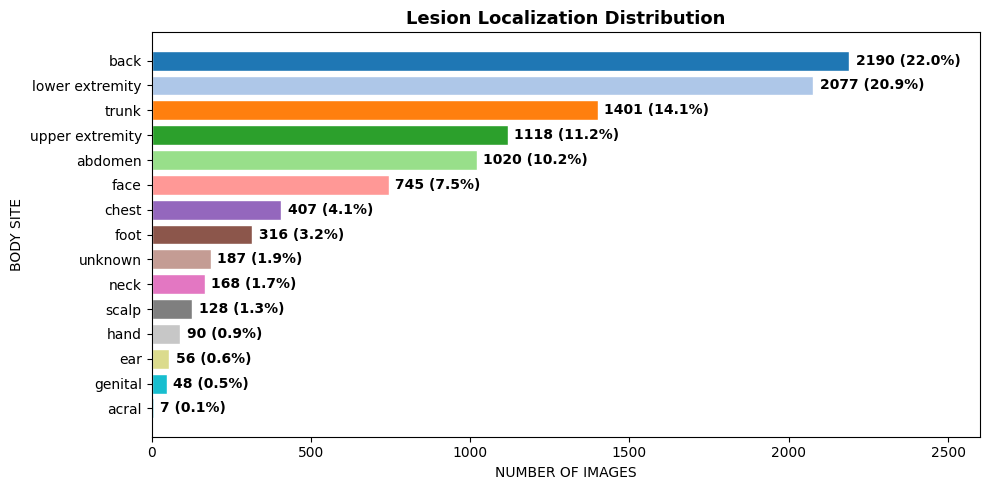

In [13]:
# Counting the frequency of each body location given
loc_counts = df['localization'].value_counts()

# Generating a color spectrum for each localization
colors_loc = plt.cm.tab20(np.linspace(0, 1, len(loc_counts)))

plt.figure(figsize=(10, 5))

# Most frequent to Least frequent lesion location
plt.barh(loc_counts.index[::-1], loc_counts.values[::-1], color=colors_loc[::-1], edgecolor='white')
for i, (val, name) in enumerate(zip(loc_counts.values[::-1], loc_counts.index[::-1])):
    plt.text(val + 20, i, f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10, fontweight='bold')

plt.title('Lesion Localization Distribution', fontsize=13, fontweight='bold')
plt.xlabel('NUMBER OF IMAGES')
plt.ylabel('BODY SITE')
plt.xlim(0, 2600)
plt.tight_layout()
plt.show()

### **PLOT 6**   --   Correlation of the Features : *Heatmap*

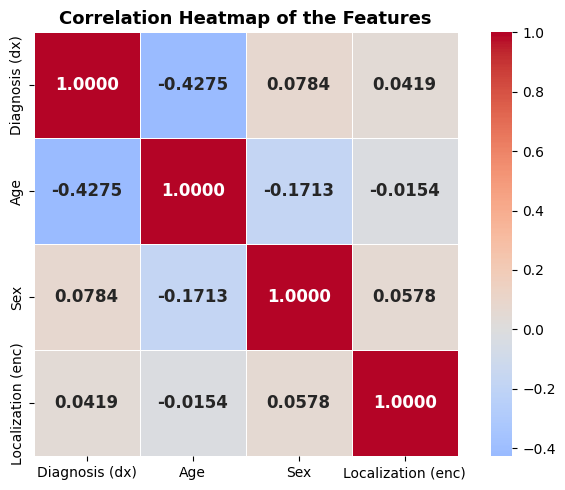

In [14]:
# Selecting only the numeric columns relevant for the analysis
corr_df = df[['dx', 'age', 'sex', 'localization_enc']].copy()
corr_df.columns = ['Diagnosis (dx)', 'Age', 'Sex', 'Localization (enc)']
plt.figure(figsize=(7, 5))

# Correlation value printed inside each cell; blue = negative, red = positive, center = neutral
sns.heatmap(corr_df.corr(), annot=True, fmt='.4f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'shrink': 1.0})

plt.title('Correlation Heatmap of the Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **Part 2:** Image EDA

### *7. Load & Filter the Images*

In [ ]:
# Attaching image paths using the pre-built lookup dictionary and avoid creating extra dictionaries
df['img_path'] = df['image_id'].map(image_path_dict)

# If image file not found, remove rows
df_img = df.dropna(subset=['img_path']).copy()

df_img = df_img[~df_img['image_id'].isin(EXCLUDE_IDS)]

print('=' * 35)
print(' IMAGES SUMMARY')
print('=' * 35)
print(f'Total Indexed Images       : {len(image_path_dict):,}')
print(f'Excluded IDs (no metadata) : {len(EXCLUDE_IDS)}')
print(f'Matched Metadata Rows      : {len(df_img):,}')
print(f'Unmatched Metadata Rows    : {df["img_path"].isna().sum()}')

 IMAGES SUMMARY
Total Indexed Images       : 10,015
Excluded IDs (no metadata) : 57
Matched Metadata Rows      : 9,958
Unmatched Metadata Rows    : 0


### **PLOT 7**   --   Sample Image Grid : *Image Representation*

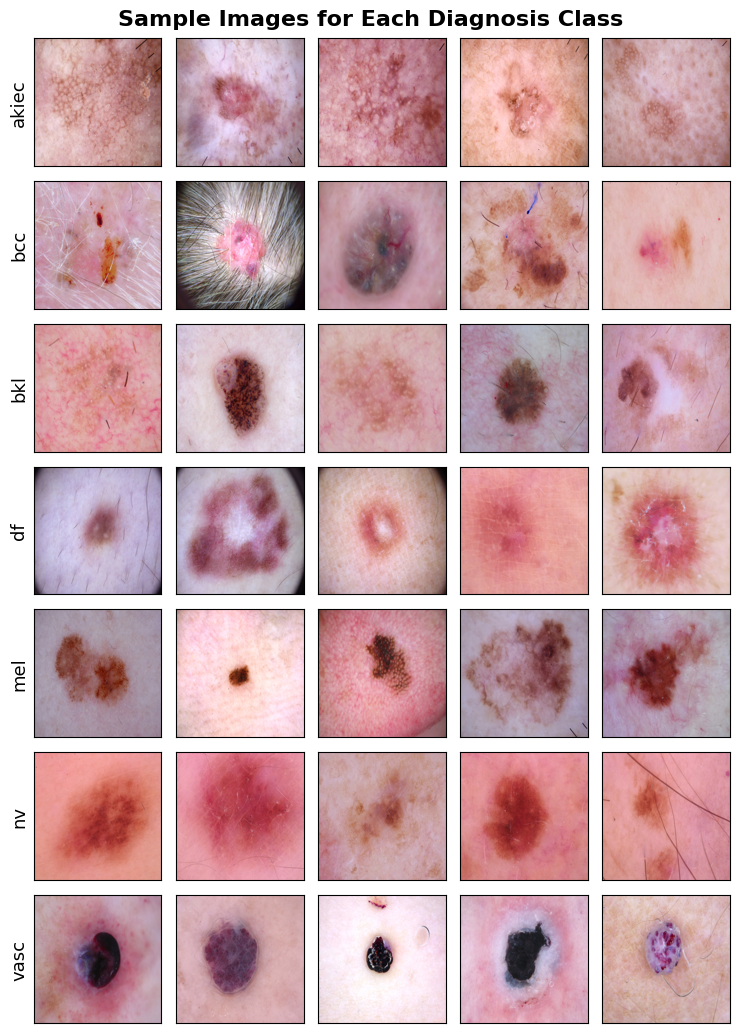

In [ ]:
# Selecting 5 images from each class to represent all identified diagnosis
n_samples = 5
fig, axes = plt.subplots(len(order), n_samples, figsize=(n_samples * 1.5, len(order) * 1.5))

for row_i, cls in enumerate(order):
    paths = df_img.loc[df_img['dx_label']==cls, 'img_path'].tolist()
    samples = random.sample(paths, min(n_samples, len(paths)))
    for col_i in range(n_samples):
        ax = axes[row_i][col_i]
        if col_i < len(samples):
            ax.imshow(Image.open(samples[col_i]).convert('RGB').resize((128,128)))
        else:
            ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(cls, fontsize='13')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Sample Images for Each Diagnosis Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **PLOT 8**   --   Mean Image per Class :  *Image Representation*

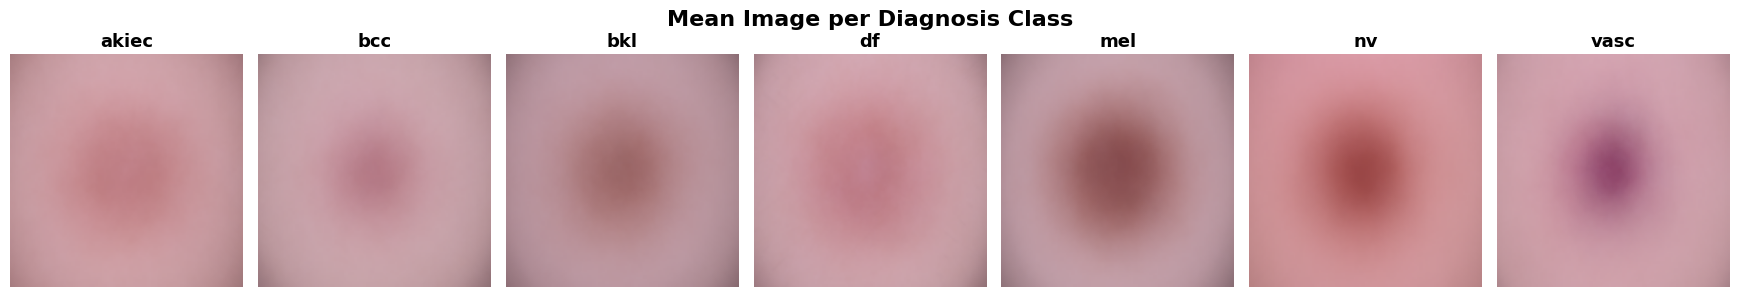

In [31]:
# Averages pixel values across images in each class
# Reveals distinct colour/texture signatures
MAX_PER_CLASS = 315

fig, axes = plt.subplots(1, len(order), figsize=(len(order) * 2.5, 3))

for i, cls in enumerate(order):
    paths  = df_img.loc[df_img['dx_label']==cls]['img_path'].tolist()
    paths  = random.sample(paths, min(MAX_PER_CLASS, len(paths)))
    arrays = [np.array(Image.open(p).convert('RGB').resize((128, 128))) for p in paths]
    mean_img = np.mean(arrays, axis=0).astype(np.uint8)

    axes[i].imshow(mean_img)
    axes[i].set_title(cls, fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Mean Image per Diagnosis Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **PLOT 9**   --   Pixel Intensity (R, G, B per Class) : *Histogram*

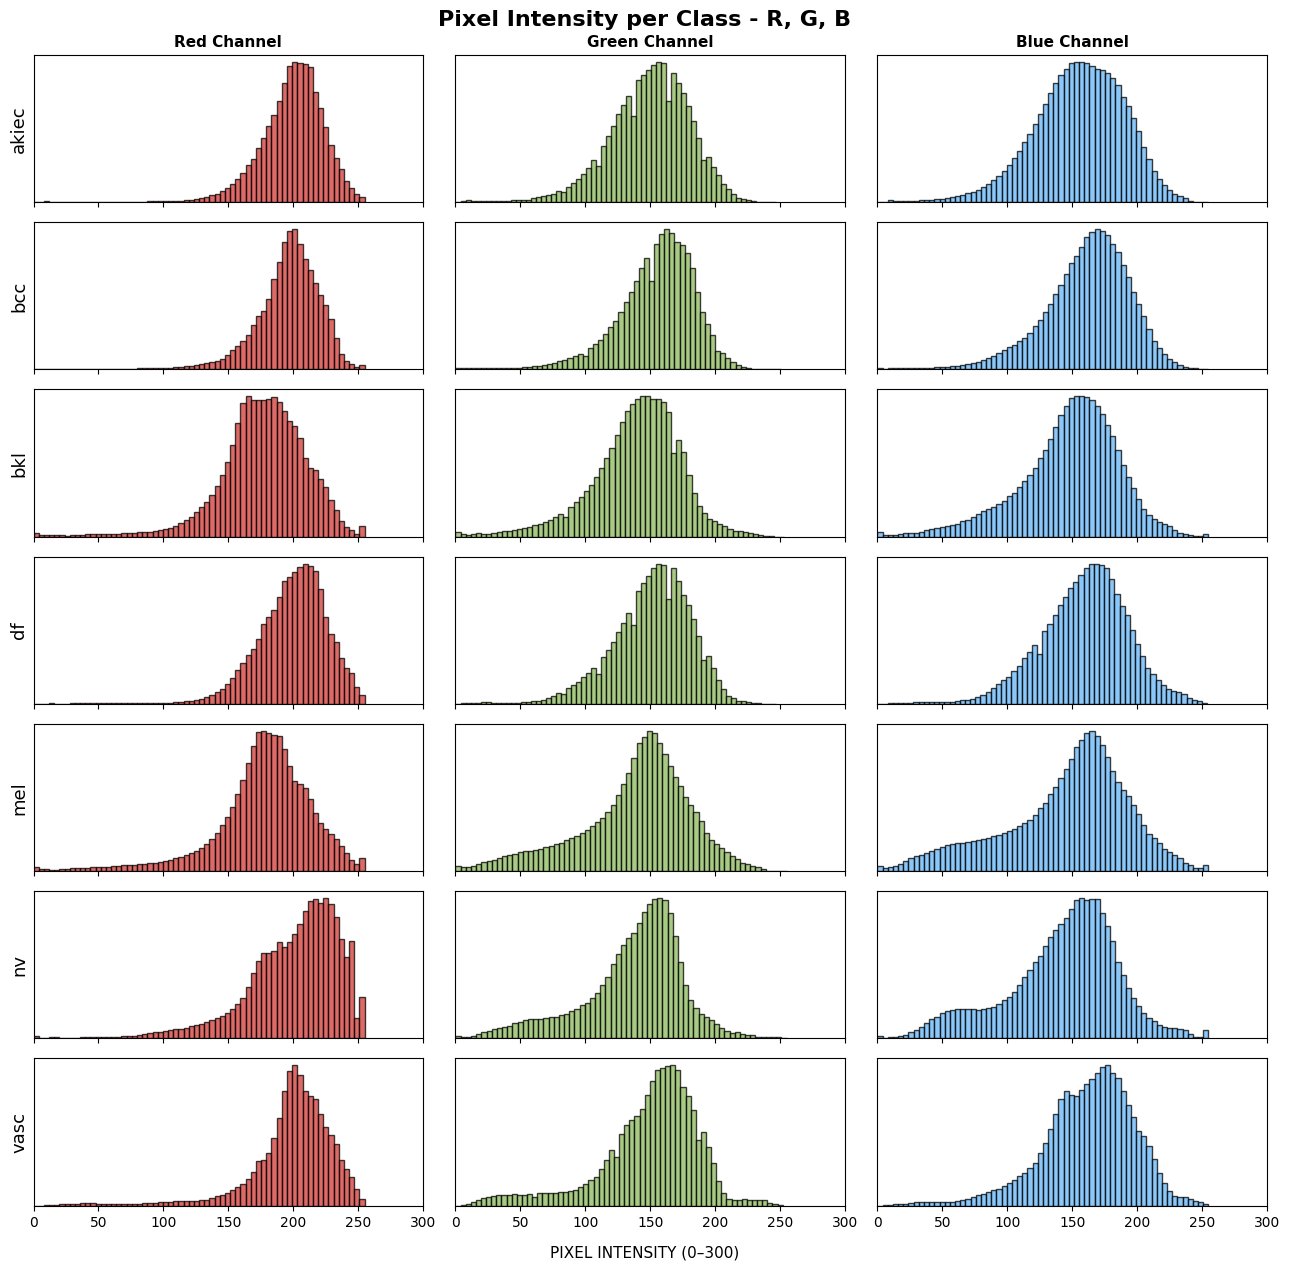

In [ ]:
# Melanoma images tend to be darker; Shows why color is a diagnostic signal
MAX_PER_CLASS = 250
channel_names  = ['Red', 'Green', 'Blue']
channel_colors = ['#D13936', '#8CB95C', '#64B5F6']

# Create 1 row per diagnosis class & 1 column per colour channel
fig, axes = plt.subplots(len(order), 3, figsize=(13, len(order) * 1.8), sharex=True)

for row_i, cls in enumerate(order):
    paths  = df_img.loc[df_img['dx_label'] == cls]['img_path'].tolist()
    paths  = random.sample(paths, min(MAX_PER_CLASS, len(paths)))
    arrays = np.stack([np.array(Image.open(p).convert('RGB').resize((64, 64))) for p in paths])

# Plotting histogram for each RGB channel separately
    for ch in range(3):
        ax = axes[row_i][ch]
        ax.hist(arrays[:, :, :, ch].flatten(), 
            bins=64,
            color=channel_colors[ch], 
            alpha=0.75, 
            edgecolor='black')
        ax.set_xlim(0, 300)
        ax.set_yticks([])
        ax.spines[['top','right','left']].set_visible(True)

        if row_i == 0:
            ax.set_title(f'{channel_names[ch]} Channel', fontsize=11, fontweight='bold')
        if ch == 0:
            ax.set_ylabel(cls, fontsize='13')

plt.suptitle('Pixel Intensity per Class - R, G, B', fontsize=16, fontweight='bold')
fig.text(0.5, -0.01, 'PIXEL INTENSITY (0–300)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### **PLOT 10**   --   Image Dimension Check

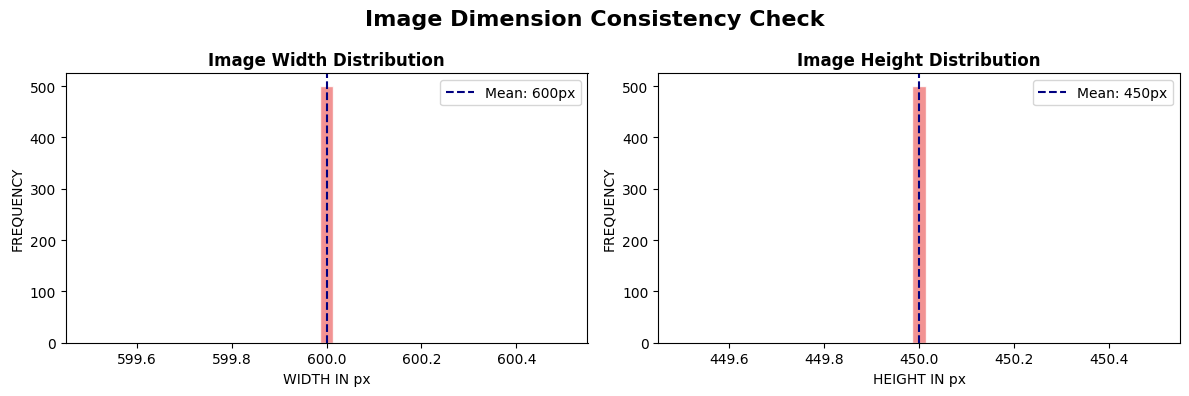

Distinct Values:
Width [600]
Height [450]


In [ ]:
# Checking the images size consistency, helps decide whether resizing is needed during preprossesing
sample_paths = random.sample(list(image_path_dict.values()), min(500, len(image_path_dict)))
widths = []
heights = []

for p in sample_paths:
    with Image.open(p) as img:
        w_px, h_px = img.size
        widths.append(w_px)
        heights.append(h_px)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title, xlabel in [
    (axes[0], widths,  'Image Width Distribution',  'WIDTH IN px'),
    (axes[1], heights, 'Image Height Distribution', 'HEIGHT IN px'),
]:
    ax.hist(data, bins=35, color='lightcoral', edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(data), color='navy', 
            linestyle='--', lw=1.5,
            label=f'Mean: {np.mean(data):.0f}px')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('FREQUENCY')
    ax.legend()
    ax.spines[['top','right']].set_visible(True)

plt.suptitle('Image Dimension Consistency Check', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# To show the numerical values of the presented plot
# Indictes that every image has the identical pixel dimensions
print('=' *20)
print("Distinct Values:")
print('=' *20)
print(f'Width {sorted(set(widths))}')
print(f'Height {sorted(set(heights))}')

### **PLOT 11**   --   Brightness Distribution per Class : *Boxplot*

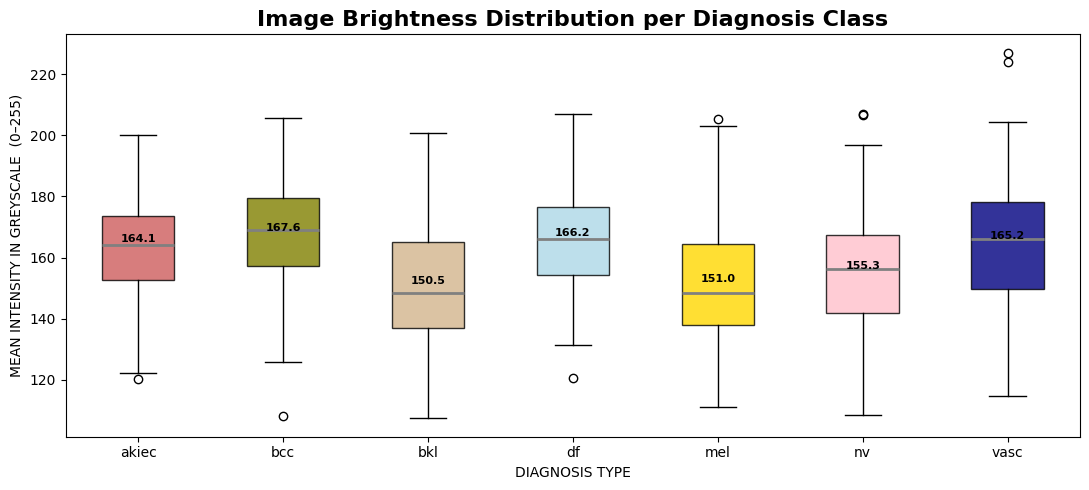

In [ ]:
# Mean pixel intensity per image, grouped by class; Shows lighting variation across classes
MAX_PER_CLASS = 150
brightness_records = []

for cls in order:
    paths = df_img.loc[df_img['dx_label'] == cls]['img_path'].tolist()
    paths = random.sample(paths, min(MAX_PER_CLASS, len(paths)))
    for p in paths:
        # Converting the images to grayscale ('L'), brightness can be measured without any pigmentations
        arr = np.array(Image.open(p).resize((64, 64)).convert('L'))                  
        brightness_records.append({'Diagnosis Type': cls, 'Mean Brightness Intenisty': arr.mean()})

bright_df = pd.DataFrame(brightness_records)

plt.figure(figsize=(11, 5))
bp = plt.boxplot([bright_df[bright_df['Diagnosis Type'] == c]['Mean Brightness Intenisty'].values for c in order],
                tick_labels=order, patch_artist=True, medianprops=dict(color='grey', linewidth=2)) 

# Apply class colours to each box
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.title('Image Brightness Distribution per Diagnosis Class', fontsize=16, fontweight='bold')
plt.xlabel('DIAGNOSIS TYPE')
plt.ylabel('MEAN INTENSITY IN GREYSCALE  (0–255)')
plt.tight_layout()
plt.show()

### **PLOT 12**   --   Skin Tone Analysis : *ITA-Based*

In [ ]:
# ITA (Individual Typology Angle) measures skin tone using the CIE Lab colour space.
# Sampled from border pixels of each image to avoid the lesion area.
# Three groups: Light (ITA > 41°), Medium (10° < ITA ≤ 41°), Dark (ITA ≤ 10°)

"""ITA = arctan((L* - 50) / b*) x (180/pi); Uses border pixels to sample skin background, excluding the lesions """

def compute_ita(img_path, border=15):

    img  = Image.open(img_path).resize((128, 128)).convert('RGB')
    arr  = np.array(img, dtype=np.float32) / 255.0

    # Sample outer border ring to avoids the central lesion
    top    = arr[:border, :].reshape(-1, 3)
    bottom = arr[-border:, :].reshape(-1, 3)
    left   = arr[border:-border, :border].reshape(-1, 3)
    right  = arr[border:-border, -border:].reshape(-1, 3)
    pixels = np.vstack([top, bottom, left, right])
    R, G, B = pixels.mean(axis=0)

    # sRGB convert to linear RGB (gamma removal)
    def gamma(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    rl, gl, bl = gamma(R), gamma(G), gamma(B)

    # Linear RGB convert XYZ (D65 illuminant)
    Y = rl * 0.2126 + gl * 0.7152 + bl * 0.0722
    Z = rl * 0.0193 + gl * 0.1192 + bl * 0.9505

    # XYZ convert to CIE L* and b*
    def f(t):
        return t ** (1/3) if t > 0.008856 else 7.787 * t + 16/116

    L_star = 116 * f(Y / 1.00000) - 16
    b_star = 200 * (f(Y / 1.00000) - f(Z / 1.08883))

    # ITA angle
    ita = np.degrees(np.arctan2(L_star - 50, b_star + 1e-6))
    return ita


def classify_tone(ita):
    if ita > 41:
        return 'Light'
    elif ita > 10:
        return 'Medium'
    else:
        return 'Dark'

In [ ]:
# Compute ITA for up to 200 images per class
MAX_PER_CLASS = 200
ita_records   = []

for cls in order:
    paths = df_img[df_img['dx_label'] == cls]['img_path'].tolist()
    paths = random.sample(paths, min(MAX_PER_CLASS, len(paths)))
    for p in paths:
        ita_val = compute_ita(p)
        ita_records.append({
            'Diagnosis': cls,
            'ITA':       ita_val,
            'Skin Tone': classify_tone(ita_val)
        })

ita_df = pd.DataFrame(ita_records)

print('=' * 45)
print(' SKIN TONE DISTRIBUTION OVER ALL IMAGES')
print('=' * 45)
tone_counts = ita_df['Skin Tone'].value_counts()
for tone, cnt in tone_counts.items():
    print(f'  {tone:<10}: {cnt:>5}  ({cnt/len(ita_df)*100:.1f}%)')

 SKIN TONE DISTRIBUTION OVER ALL IMAGES
  Light     :  1145  (91.1%)
  Medium    :    57  (4.5%)
  Dark      :    55  (4.4%)


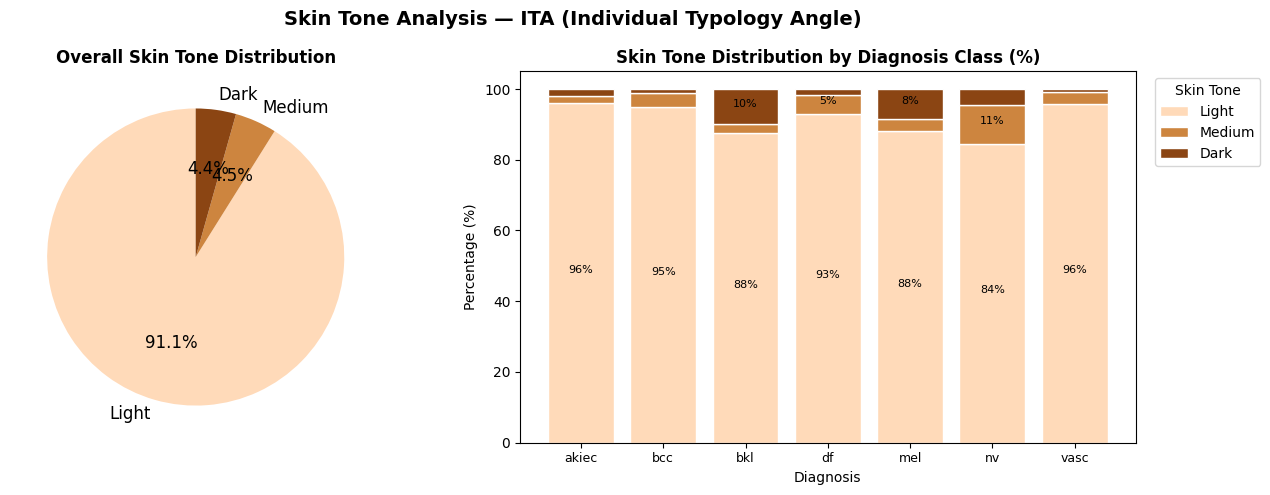

In [ ]:
TONE_order   = ['Light', 'Medium', 'Dark']
TONE_palette = ['peachpuff', 'peru', 'saddlebrown']
TONE_MAP     = dict(zip(TONE_order, TONE_palette))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall pie chart
tone_counts = ita_df['Skin Tone'].value_counts().reindex(TONE_order).fillna(0)
axes[0].pie(tone_counts.values, labels=tone_counts.index,
            autopct='%1.1f%%', colors=TONE_palette,
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Overall Skin Tone Distribution', fontsize=12, fontweight='bold')

# Per-class stacked bar
cross_tone = pd.crosstab(ita_df['Diagnosis'], ita_df['Skin Tone'])
cross_tone = cross_tone.reindex(order).reindex(columns=TONE_order, fill_value=0)
cross_pct_tone = cross_tone.div(cross_tone.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(order))
for tone, color in zip(TONE_order, TONE_palette):
    vals = cross_pct_tone[tone].values
    axes[1].bar(order, vals, bottom=bottom, label=tone, color=color, edgecolor='white')
    bottom += vals

    
    # Adding percentage (%) values to enhance readability of the skin tones analysis
    for i, v in enumerate(vals):
        if v > 5:
            axes[1].text(i, bottom[i] - v/2, f'{v:.0f}%', ha='center', fontsize=8)

axes[1].set_title('Skin Tone Distribution by Diagnosis Class (%)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Diagnosis')
axes[1].legend(title='Skin Tone', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_xticklabels(order, fontsize=9)

plt.suptitle('Skin Tone Analysis — ITA (Individual Typology Angle)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()